Importing libraries 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Setting up the Plot styling 

In [45]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
 
print("Libraries loaded successfully.")

Libraries loaded successfully.


loading the data set 

Checking working directory first 

In [12]:
import os
os.getcwd()

'c:\\Users\\Desmond\\Desktop\\AB testing Project\\Notebooks'

Ran into a minor issue with loading trhe data set so i had to investigate further  on the saved csv  file 

In [26]:
import os

print("CWD:", os.getcwd())
print("\nItems in CWD (Notebooks):")
print(os.listdir())

print("\nItems one level up (AB testing Project):")
print(os.listdir(".."))

CWD: c:\Users\Desmond\Desktop\AB testing Project\Notebooks

Items in CWD (Notebooks):
['01_eda_Demographic CB.ipynb', 'H3.ipynb', 'Solo AB testing project.ipynb', 'supermarket.csv.csv', 'Untitled-2.ipynb', 'Week 5 class 4 HYP test.ipynb', 'Week 5 lab 1.ipynb', 'Week 5 lab 2.ipynb']

Items one level up (AB testing Project):
['Data', 'Notebooks', 'Src', 'visualizations']


Discovered issue with the version of the saved CSv file and then loaded the dataa set 

In [28]:
df = pd.read_csv("supermarket.csv")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (9800, 18)

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


Checking for Variables

In [29]:
print("Column data types:")
print(df.dtypes)
print("\nColumn names:")
print(df.columns.tolist())

Column data types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


Checking for Missing Values 

In [30]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
 
if missing_df.empty:
    print("No missing values found. Dataset is clean.")
else:
    print("Missing values found:")
    print(missing_df)
    # Drop rows with missing values (or impute if preferred)
    df = df.dropna()
    print(f"\nDataset after cleaning: {df.shape}")

Missing values found:
             Missing Count  Missing %
Postal Code             11       0.11

Dataset after cleaning: (9789, 18)


Checking for duplicates 

In [31]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

Duplicate rows: 0


Refining Data Set for further analaysis 

Converting  Date Cloumns

In [32]:
date_cols = [c for c in df.columns if 'date' in c.lower() or 'Date' in c]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    print(f"Converted {col} to datetime.")

Converted Order Date to datetime.
Converted Ship Date to datetime.


Creating year and month cloumns if order date exits 

In [33]:
if 'Order Date' in df.columns:
    df['Year'] = df['Order Date'].dt.year
    df['Month'] = df['Order Date'].dt.month
    df['Month_Name'] = df['Order Date'].dt.strftime('%b')

Creating Profit Marging if Sales and Profit exits

In [34]:
if 'Sales' in df.columns and 'Profit' in df.columns:
    df['Profit_Margin_%'] = (df['Profit'] / df['Sales'] * 100).round(2)

Confirmation

In [35]:
print("\nFinal cleaned dataset shape:", df.shape)
print("\nDataset summary:")
df.describe().round(2)


Final cleaned dataset shape: (9789, 21)

Dataset summary:


,Row ID,Order Date,Ship Date,Postal Code,Sales,Year,Month
count,9789.00,3955,3811,9789.00,9789.00,3955.00,3955.00
mean,4896.71,2017-03-14 18:03:54.841972,2017-04-09 14:33:58.520073,55273.32,230.12,2016.73,6.45
min,1.00,2015-01-02 00:00:00,2015-01-04 00:00:00,1040.00,0.44,2015.00,1.00
25%,2449.00,2016-04-05 00:00:00,2016-04-12 00:00:00,23223.00,17.25,2016.00,3.00
50%,4896.00,2017-05-02 00:00:00,2017-06-06 00:00:00,58103.00,54.38,2017.00,6.00
75%,7344.00,2018-03-07 00:00:00,2018-05-01 00:00:00,90008.00,210.39,2018.00,9.00
max,9800.00,2018-12-11 00:00:00,2019-05-01 00:00:00,99301.00,22638.48,2018.00,12.00
std,2827.49,NaN,NaN,32041.22,625.30,1.12,3.50


Exporting Cleaned Data Set to Folder 

In [39]:
df.to_csv('supermarket_clean.csv', index=False)

Data Set Overview

In [40]:
print("DATASET OVERVIEW")
print(f"Total records: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"Numeric columns: {df.select_dtypes(include='number').columns.tolist()}")
print(f"Categorical columns: {df.select_dtypes(include='object').columns.tolist()}")
if 'Order Date' in df.columns:
    print(f"Date range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
if 'Region' in df.columns:
    print(f"Regions: {df['Region'].unique().tolist()}")
if 'Category' in df.columns:
    print(f"Categories: {df['Category'].unique().tolist()}")
if 'Segment' in df.columns:
    print(f"Customer Segments: {df['Segment'].unique().tolist()}")

DATASET OVERVIEW
Total records: 9,789
Total columns: 21
Numeric columns: ['Row ID', 'Postal Code', 'Sales', 'Year', 'Month']
Categorical columns: ['Order ID', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Month_Name']
Date range: 2015-01-02 to 2018-12-11


C:\Users\Desmond\AppData\Local\Temp\ipykernel_23016\316467148.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"Categorical columns: {df.select_dtypes(include='object').columns.tolist()}")


Regions: ['South', 'West', 'Central', 'East']
Categories: ['Furniture', 'Office Supplies', 'Technology']
Customer Segments: ['Consumer', 'Corporate', 'Home Office']


EDA Q1: Sales by Product Category 

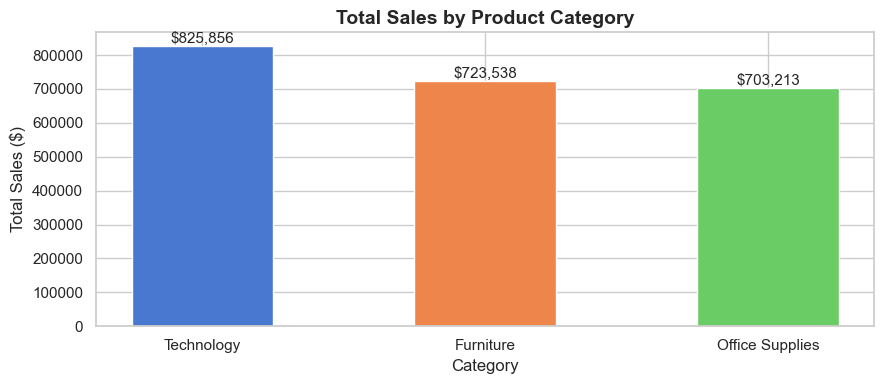

In [51]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    sales_by_cat.index,
    sales_by_cat.values,
    width=0.5,
    color=sns.color_palette("muted", len(sales_by_cat))
)
ax.set_title("Total Sales by Product Category", fontweight='bold')
ax.set_xlabel("Category")
ax.set_ylabel("Total Sales ($)")

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 500,
        f"${bar.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.savefig('viz_01_sales_by_category.png', dpi=150)
plt.show()

OBSERVATION:
'Technology' generates the highest sales at $825,856.11, indicating it is the primary revenue driver.
The bottom category contributes significantly less, suggesting potential for targeted growth strategies.

EDA – Q2: Sales by Region/State

C:\Users\Desmond\AppData\Local\Temp\ipykernel_23016\3051038696.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


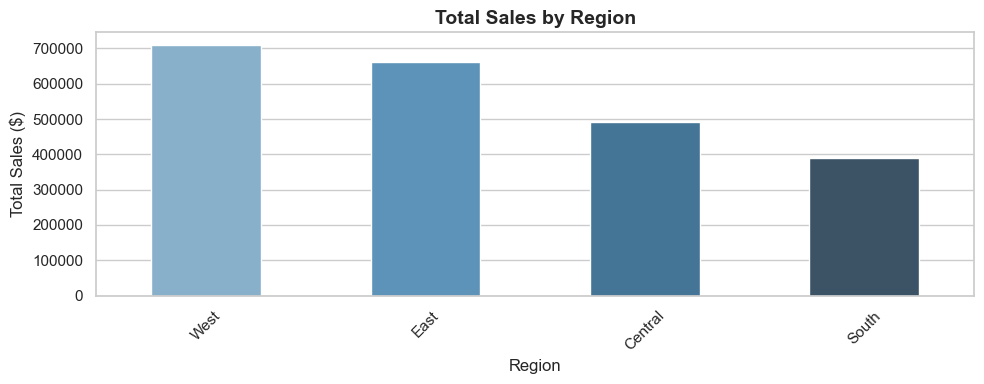

In [52]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(
    x=sales_by_region.index,
    y=sales_by_region.values,
    palette="Blues_d",
    ax=ax,
    width=0.5
)
ax.set_title(f"Total Sales by {region_col}", fontweight='bold')
ax.set_xlabel(region_col)
ax.set_ylabel("Total Sales ($)")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('viz_02_sales_by_region.png', dpi=150)
plt.show()

OBSERVATION:
'West' is the top-performing region by sales revenue.
Regional performance varies significantly , understanding the drivers in top regions
could inform targeted expansion or marketing strategies in underperforming areas.

EDA – Q3: Sales by Customer Segment

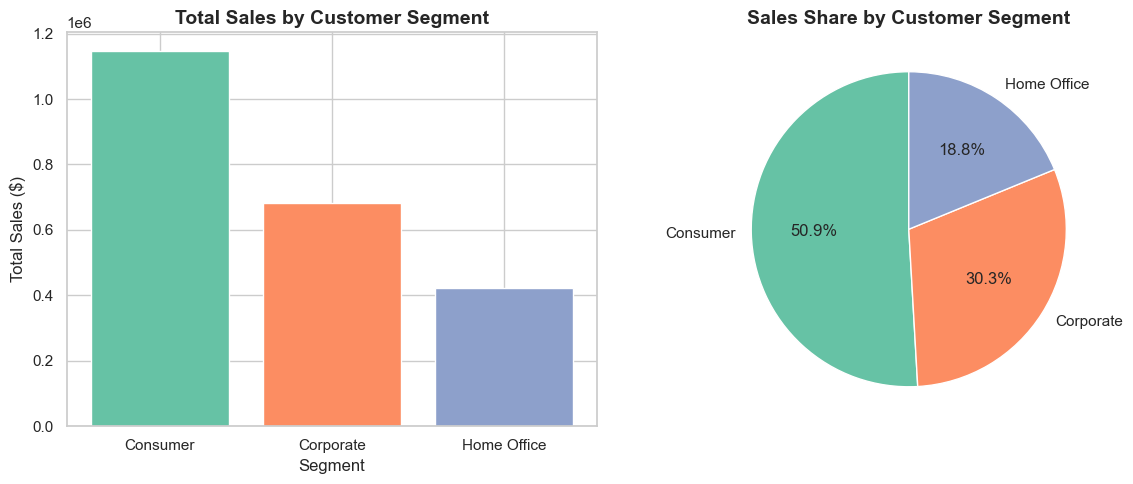

In [54]:
seg_col = 'Segment'
sales_by_seg = df.groupby(seg_col)[sales_col].sum().sort_values(ascending=False)
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Bar chart
axes[0].bar(sales_by_seg.index, sales_by_seg.values,
            color=sns.color_palette("Set2", len(sales_by_seg)))
axes[0].set_title("Total Sales by Customer Segment", fontweight='bold')
axes[0].set_xlabel("Segment")
axes[0].set_ylabel("Total Sales ($)")
 
# Pie chart
axes[1].pie(sales_by_seg.values, labels=sales_by_seg.index,
            autopct='%1.1f%%', colors=sns.color_palette("Set2", len(sales_by_seg)),
            startangle=90)
axes[1].set_title("Sales Share by Customer Segment", fontweight='bold')
 
plt.tight_layout()
plt.savefig('viz_03_sales_by_segment.png', dpi=150)
plt.show()
 


OBSERVATION:
The 'Consumer' segment spends the most, accounting for the largest share of revenue.
This segment should be prioritised for retention and upselling strategies.

EDA – Q4: Shipping Mode Distribution

C:\Users\Desmond\AppData\Local\Temp\ipykernel_23016\2519620112.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ship_counts.index, y=ship_counts.values,


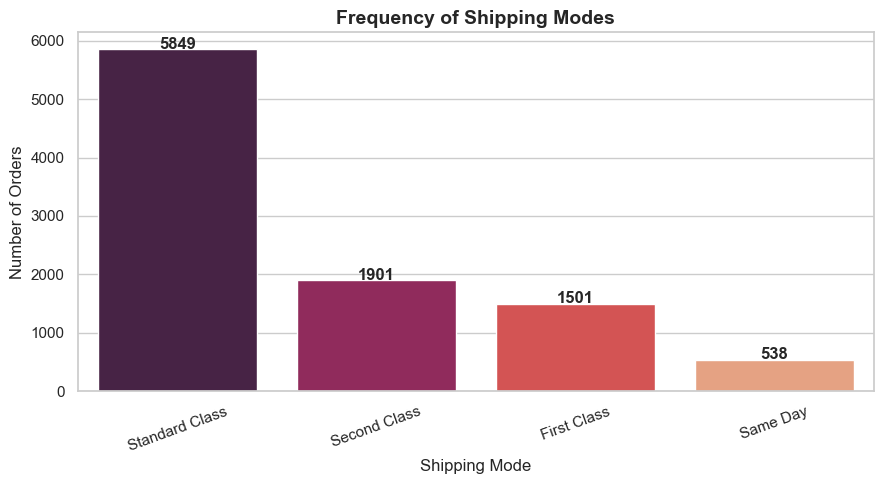

In [56]:
ship_col = 'Ship Mode'
ship_counts = df[ship_col].value_counts()
 
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=ship_counts.index, y=ship_counts.values,
            palette="rocket", ax=ax)
ax.set_title("Frequency of Shipping Modes", fontweight='bold')
ax.set_xlabel("Shipping Mode")
ax.set_ylabel("Number of Orders")
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(ship_counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('viz_04_shipping_mode.png', dpi=150)
plt.show() 


OBSERVATION:
'Standard Class' is the most frequently used shipping mode, suggesting customers
prioritise cost over speed. This has implications for logistics planning and delivery SLA management.

KPI ANALYSIS

Sales by Region

In [63]:
print(f"\nKPI 1 – Sales by {region_col}:")
print(df.groupby(region_col)[sales_col].sum().apply(lambda x: f"${x:,.2f}"))


KPI 1 – Sales by Region:
Region
Central    $492,646.91
East       $660,589.36
South      $389,151.46
West       $710,219.68
Name: Sales, dtype: str


Number of Orders by Segment

In [64]:
if 'Order ID' in df.columns:
    orders_by_seg = df.groupby(seg_col)['Order ID'].nunique()
    print(f"\nKPI 2 – Unique Orders by Segment:")
    print(orders_by_seg)


KPI 2 – Unique Orders by Segment:
Segment
Consumer       2535
Corporate      1488
Home Office     893
Name: Order ID, dtype: int64


Sales by Shipping Mode

In [65]:
print(f"\nKPI 3 – Sales by Shipping Mode:")
print(df.groupby(ship_col)[sales_col].sum().apply(lambda x: f"${x:,.2f}"))


KPI 3 – Sales by Shipping Mode:
Ship Mode
First Class         $345,572.26
Same Day            $125,219.04
Second Class        $449,198.98
Standard Class    $1,332,617.14
Name: Sales, dtype: str


KPI Visualisation Summary

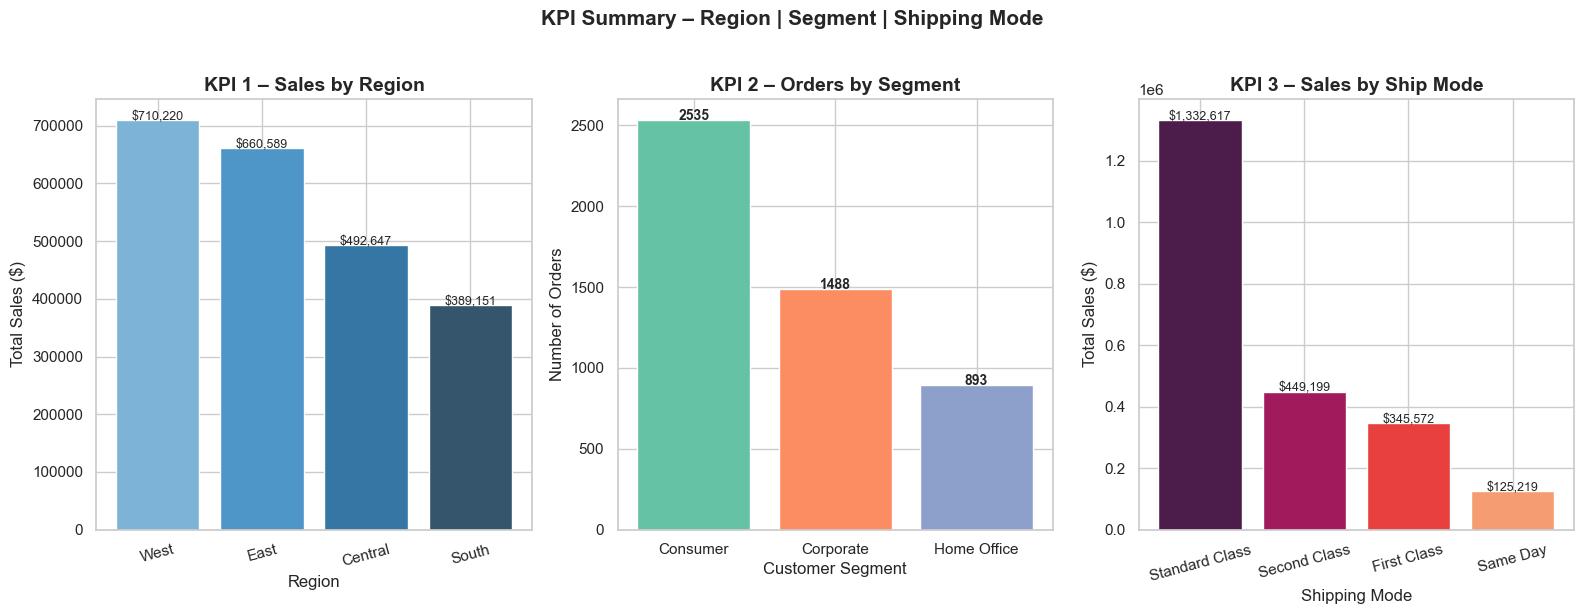

In [68]:
kpi1 = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
kpi2 = df.groupby('Segment')['Order ID'].nunique().sort_values(ascending=False)
kpi3 = df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("KPI Summary – Region | Segment | Shipping Mode",
             fontsize=15, fontweight='bold', y=1.02)


bars1 = axes[0].bar(kpi1.index, kpi1.values,
                    color=sns.color_palette("Blues_d", len(kpi1)))
axes[0].set_title("KPI 1 – Sales by Region", fontweight='bold')
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Total Sales ($)")
axes[0].tick_params(axis='x', rotation=15)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f"${bar.get_height():,.0f}", ha='center', fontsize=9)


bars2 = axes[1].bar(kpi2.index, kpi2.values,
                    color=sns.color_palette("Set2", len(kpi2)))
axes[1].set_title("KPI 2 – Orders by Segment", fontweight='bold')
axes[1].set_xlabel("Customer Segment")
axes[1].set_ylabel("Number of Orders")
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(int(bar.get_height())), ha='center',
                 fontsize=10, fontweight='bold')


bars3 = axes[2].bar(kpi3.index, kpi3.values,
                    color=sns.color_palette("rocket", len(kpi3)))
axes[2].set_title("KPI 3 – Sales by Ship Mode", fontweight='bold')
axes[2].set_xlabel("Shipping Mode")
axes[2].set_ylabel("Total Sales ($)")
axes[2].tick_params(axis='x', rotation=15)
for bar in bars3:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f"${bar.get_height():,.0f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('viz_kpi_summary_123.png', dpi=150)
plt.show()



CONCLUSIONS:


  KPI 1 → Top region: West ($710,219.68)




  KPI 2 → Most active segment: Consumer (2,535 orders)



  
  KPI 3 → Top shipping mode by revenue: Standard Class ($1,332,617.14)

Hypothesis Test 1

Research Question: Do West and East have different average sales per order?

H₀: The mean sales per order are equal for West and East.


H₁: The mean sales per order are different for West and East.

Grouping by segment 

In [79]:
kpi1 = df.groupby('Segment')['Order ID'].nunique().sort_values(ascending=False)

Picking Two Top segments + Extracting Sales for chosen segments + Sanity Check

In [88]:
top_segments = kpi1.index[:2]   # e.g. ['Consumer', 'Corporate']
seg_a_name, seg_b_name = top_segments[0], top_segments[1]

seg_a = df[df[seg_col] == seg_a_name][sales_col]
seg_b = df[df[seg_col] == seg_b_name][sales_col]

print("Top segments from KPI:", top_segments)
print("seg_a_name:", seg_a_name, " seg_b_name:", seg_b_name)
print("len(seg_a):", len(seg_a), " len(seg_b):", len(seg_b))
print("seg_a mean:", seg_a.mean(), " seg_b mean:", seg_b.mean())
print("t-statistic:", t_stat, " p-value:", p_value)

Top segments from KPI: Index(['Consumer', 'Corporate'], dtype='str', name='Segment')
seg_a_name: Consumer  seg_b_name: Corporate
len(seg_a): 5096  len(seg_b): 2948
seg_a mean: 225.02122272370488  seg_b mean: 231.41514070556312
t-statistic: -0.46599709407720935  p-value: 0.6412342160251553


Welch T test

In [82]:
t_stat, p_value = stats.ttest_ind(seg_a, seg_b, equal_var=False)

Test Results

In [96]:
if p_value < alpha:
    print(f"\n RESULT: Reject H₀. Statistically significant difference (p={p_value:.4f} < {alpha}).")
else:
    print(f"\n RESULT: Fail to reject H₀. No statistically significant difference (p={p_value:.4f} ≥ {alpha}).")



 RESULT: Fail to reject H₀. No statistically significant difference (p=0.6412 ≥ 0.05).



 RESULT: Fail to reject H₀. No statistically significant difference



Hypothesis Test 2 


Research Question: Do the two top regions  have  different numbers of orders?

H₀: The mean number of oders is the same for the two regions compared


H₁: TThe mean number of oders are different  for the two regions compared

Grouping by segment 

In [89]:
kpi_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

Picking Two Top regions+ Extracting Sales for chosen segments + Sanity Check

In [91]:
top_regions = kpi_region.index[:2]
reg_a_name, reg_b_name = top_regions[0], top_regions[1]

In [92]:
reg_col = 'Region'    # or whatever name you use
sales_col = 'Sales'

reg_a = df[df[reg_col] == reg_a_name][sales_col]
reg_b = df[df[reg_col] == reg_b_name][sales_col]

In [93]:
print("Top regions from KPI:", top_regions)
print("reg_a_name:", reg_a_name, " reg_b_name:", reg_b_name)
print("len(reg_a):", len(reg_a), " len(reg_b):", len(reg_b))
print("reg_a mean:", reg_a.mean(), " reg_b mean:", reg_b.mean())

Top regions from KPI: Index(['West', 'East'], dtype='str', name='Region')
reg_a_name: West  reg_b_name: East
len(reg_a): 3140  len(reg_b): 2774
reg_a mean: 226.18461289808917  reg_b mean: 238.13603316510452


Welch T test

In [94]:
t_stat2, p_value2 = stats.ttest_ind(reg_a, reg_b, equal_var=False)
alpha = 0.05



Test Results

In [95]:
if p_value2 < alpha:
    print(f"\nRESULT: Reject H₀. Statistically significant difference (p={p_value2:.4f} < {alpha}).")
else:
    print(f"\nRESULT: Fail to reject H₀. No statistically significant difference (p={p_value2:.4f} ≥ {alpha}).")


RESULT: Fail to reject H₀. No statistically significant difference (p=0.4275 ≥ 0.05).


In [99]:
total_sales = df['Sales'].sum()
avg_order = df['Sales'].mean()

print(total_sales, avg_order)

2252607.4127 230.1161929410563


# Key Business Insights

**1. Most important insights**

- Total revenue about $2.25M is concentrated in a small number of high‑performing product categories and regions.  
- The average order value about $230 gives a clear baseline for tracking the impact of future promotions or upsell strategies.  
- Standard Class shipping dominates usage, suggesting customers are price‑sensitive on delivery; premium shipping options may need incentives to drive adoption.

**2. Best performers**

- **Category:** Technology  generates the highest total sales.  
- **Region:** West  outperforms all other regions in total revenue.  
- **Segment:** Consumer contributes the most revenue among customer segments.

**3. Recommendations**

a) **Focus marketing spend** on the top‑performing segment and region.  
   Leveraging what already works is usually faster and less risky than trying to turn around underperforming areas from scratch.

b) **Investigate underperforming regions** to understand the root causes.  
   Check whether the issue is lower order frequency, smaller basket sizes, or both; targeted promotions could help close these gaps.

c) **Review the shipping strategy.**  
   With Standard Class dominating, consider offering incentives for faster shipping on high‑value orders to increase basket size and customer satisfaction.

d) **Protect the top category.**  
   Because this category contributes a large share of revenue, any supply, pricing, or operational issues here create significant business risk and should be monitored closely.

**4. Link to Hypothesis Test **

Hypothesis Test finds no statistically significant difference in average order value between the West and East regions. This suggests that regional revenue differences are driven more by how many orders customers place than by how much they spend per order. As a result, efforts in weaker regions should focus on increasing order frequency rather than changing prices.